# SARIMAX - Seasonal ARIMA model with eXogenous regressors

In [26]:
#this example is taken from statsmodels documntation
#https://www.statsmodels.org/stable/examples/notebooks/generated/statespace_sarimax_stata.html

In [27]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import statsmodels.api as sm
import matplotlib.pyplot as plt
from datetime import datetime
import requests
from io import BytesIO
# Register converters to avoid warnings
pd.plotting.register_matplotlib_converters()
plt.rc("figure", figsize=(16,8))
plt.rc("font", size=14)

First example uses  U.S. Wholesale Price Index (WPI) dataset. 
ARIMA(1,1,1) model is applied

In [31]:
wpi1 = requests.get('https://www.stata-press.com/data/r12/wpi1.dta').content
data = pd.read_stata(BytesIO(wpi1))
data.index = data.t
# Set the frequency
#"QS-OCT" - Quarterly Start (QS) anchored in October. 
#pandas alias, used to define time series data that begins in October and has a quarterly frequency
data.index.freq="QS-OCT" 

# Fit the model
mod = sm.tsa.statespace.SARIMAX(data['wpi'], trend='c', order=(1,1,1))
res = mod.fit(disp=False)
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                    wpi   No. Observations:                  124
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -135.351
Date:                Fri, 10 Apr 2026   AIC                            278.703
Time:                        15:38:21   BIC                            289.951
Sample:                    01-01-1960   HQIC                           283.272
                         - 10-01-1990                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0943      0.068      1.389      0.165      -0.039       0.227
ar.L1          0.8742      0.055     16.028      0.000       0.767       0.981
ma.L1         -0.4120      0.100     -4.119      0.0

In [28]:
# Dataset
data = pd.read_stata(BytesIO(wpi1))
data.index = data.t
data.index.freq="QS-OCT"

data['ln_wpi'] = np.log(data['wpi'])
data['D.ln_wpi'] = data['ln_wpi'].diff()

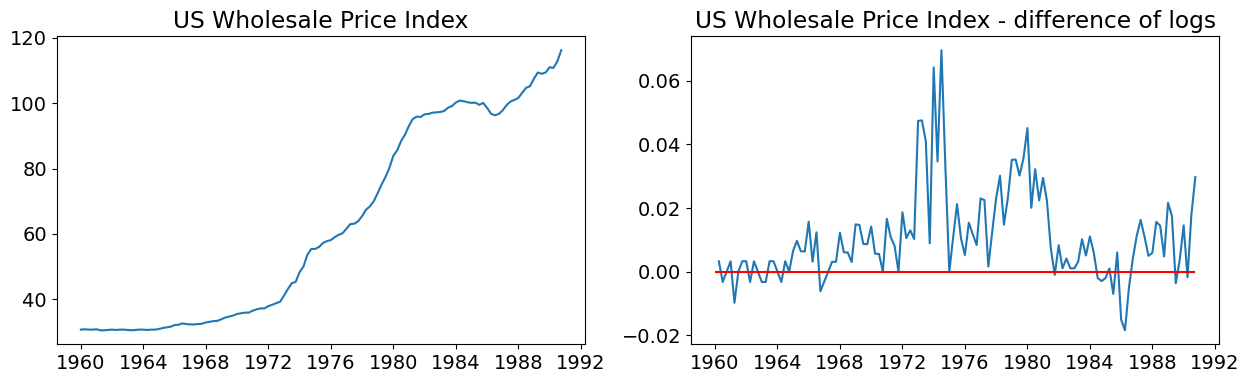

In [29]:
# Graph data
fig, axes = plt.subplots(1, 2, figsize=(15,4))

# Levels
axes[0].plot(data.index._mpl_repr(), data['wpi'], '-')
axes[0].set(title='US Wholesale Price Index')

# Log difference
axes[1].plot(data.index._mpl_repr(), data['D.ln_wpi'], '-')
axes[1].hlines(0, data.index[0], data.index[-1], 'r')
axes[1].set(title='US Wholesale Price Index - difference of logs');

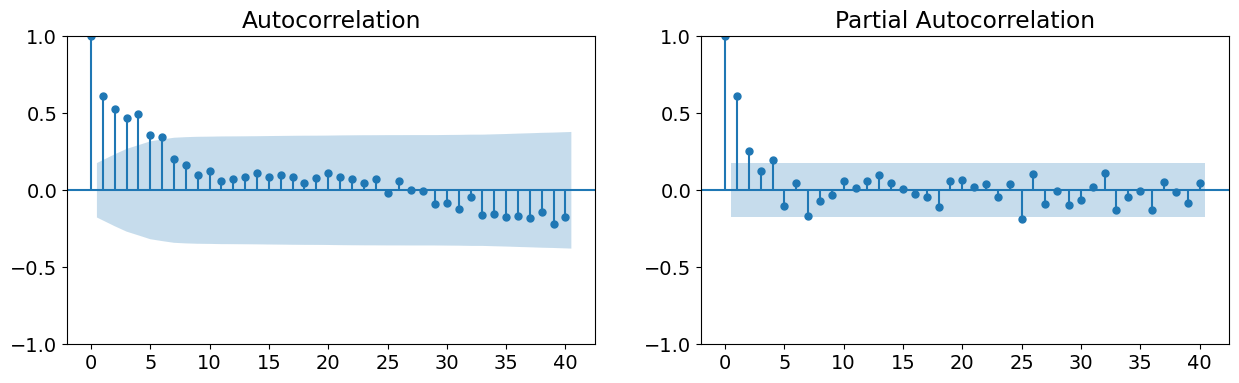

In [5]:
# Graph data
fig, axes = plt.subplots(1, 2, figsize=(15,4))

fig = sm.graphics.tsa.plot_acf(data.iloc[1:]['D.ln_wpi'], lags=40, ax=axes[0])
fig = sm.graphics.tsa.plot_pacf(data.iloc[1:]['D.ln_wpi'], lags=40, ax=axes[1])

Now seasonality component is added to ARIMA(p,d,q) model:
$$ARIMA(p,d,q)\times(P,D,Q)_4$$


In [32]:
ar = 1          # this is the maximum degree specification
ma = (1,0,0,1)  # this is the lag polynomial specification
mod = sm.tsa.statespace.SARIMAX(data['wpi'], trend='c', order=(ar,1,ma))

In [33]:
# Fit the model
mod = sm.tsa.statespace.SARIMAX(data['ln_wpi'], trend='c', order=(1,1,(1,0,0,1)))
res = mod.fit(disp=False)
print(res.summary())

                                 SARIMAX Results                                 
Dep. Variable:                    ln_wpi   No. Observations:                  124
Model:             SARIMAX(1, 1, [1, 4])   Log Likelihood                 386.033
Date:                   Fri, 10 Apr 2026   AIC                           -762.067
Time:                           15:48:12   BIC                           -748.006
Sample:                       01-01-1960   HQIC                          -756.355
                            - 10-01-1990                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0024      0.002      1.489      0.137      -0.001       0.006
ar.L1          0.7798      0.095      8.251      0.000       0.595       0.965
ma.L1         -0.3982      0

Example of ARIMA model with multiplicative seasonal effect - monthly airline data:
$$ARIMA(2,1,0)\times(1,1,0)_{12}$$

In [8]:
# Dataset
air2 = requests.get('https://www.stata-press.com/data/r12/air2.dta').content
data = pd.read_stata(BytesIO(air2))
data.index = pd.date_range(start=datetime(int(data.time[0]), 1, 1), periods=len(data), freq='MS')
data['lnair'] = np.log(data['air'])

# Fit the model
mod = sm.tsa.statespace.SARIMAX(data['lnair'], order=(2,1,0), seasonal_order=(1,1,0,12), simple_differencing=True)
res = mod.fit(disp=False)
print(res.summary())

                                     SARIMAX Results                                      
Dep. Variable:                       D.DS12.lnair   No. Observations:                  131
Model:             SARIMAX(2, 0, 0)x(1, 0, 0, 12)   Log Likelihood                 240.821
Date:                            Fri, 10 Apr 2026   AIC                           -473.643
Time:                                    13:43:12   BIC                           -462.142
Sample:                                02-01-1950   HQIC                          -468.970
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4057      0.080     -5.045      0.000      -0.563      -0.248
ar.L2         -0.0799      0.099   

# SPY intraday data


$𝑦_𝑡$ - trading volume at time $𝑡$

Data frequency: 5-minute intervals 

Trading day length: 6.5 hours = 390 minutes 

Number of observations per day: $𝑠=390/5=78$ -seasonality period


In [36]:
import yfinance as yf
import pandas as pd

# Download 1 month of 5-min SPY data
spy = yf.download(
    "SPY",
    period="1mo",
    interval="5m",
    auto_adjust=True
)

# Keep only volume
y = spy['Volume']

# Remove non-trading hours (just in case)
y = y.between_time("09:30", "16:00")

print(y.head())

[*********************100%***********************]  1 of 1 completed

Ticker                         SPY
Datetime                          
2026-03-11 13:30:00+00:00  3562491
2026-03-11 13:35:00+00:00   852127
2026-03-11 13:40:00+00:00   837445
2026-03-11 13:45:00+00:00  1085181
2026-03-11 13:50:00+00:00   910581


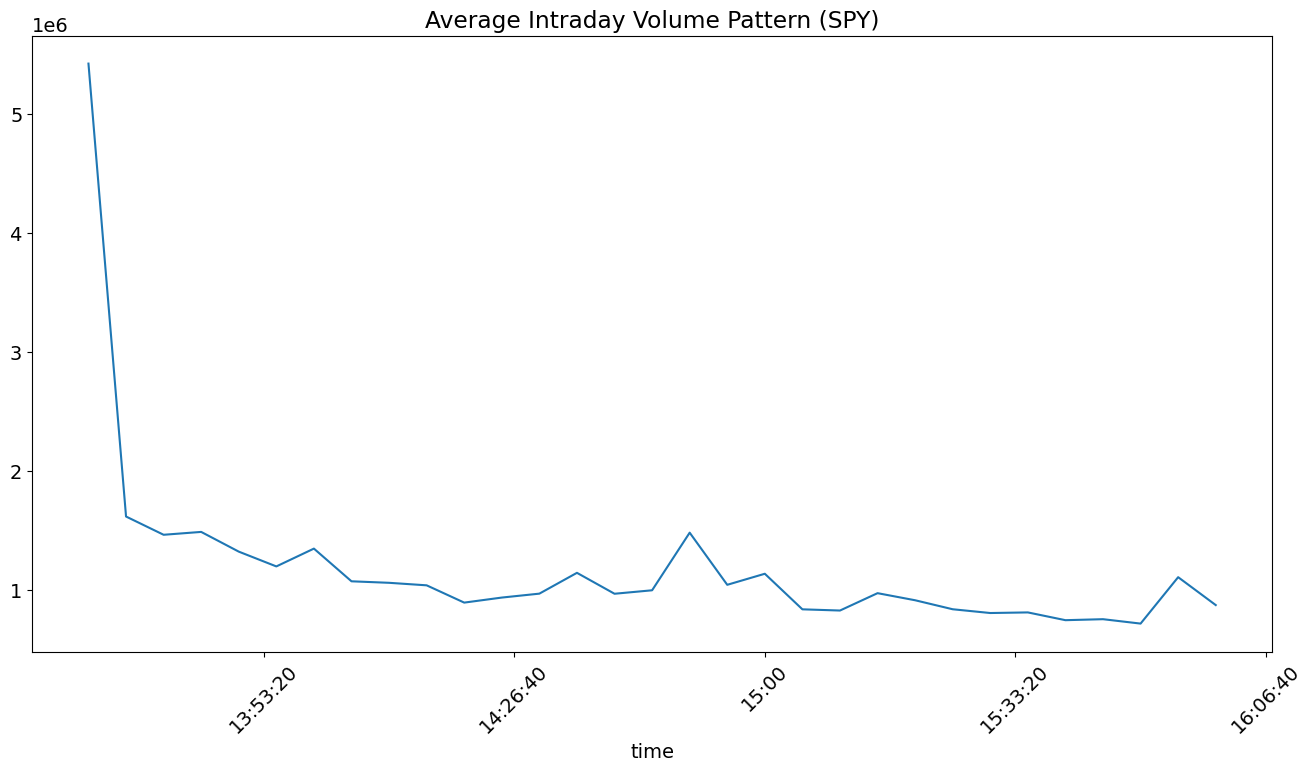

In [12]:
import matplotlib.pyplot as plt

# Average volume by time-of-day (average time-of-day across all days)
intraday_pattern = y.groupby(y.index.time).mean()

plt.plot(intraday_pattern)
plt.title("Average Intraday Volume Pattern (SPY)")
plt.xticks(rotation=45)
plt.show()

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
y_log = np.log(y + 1)
y_log = y_log.dropna().reset_index(drop=True)

model = SARIMAX(
    y_log,
    order=(1,0,1),
    seasonal_order=(1,1,1,78),
    enforce_stationarity=False,
    enforce_invertibility=False
)

print("Start fitting...")

results = model.fit(method="lbfgs", maxiter=50, disp=True)
sarima_fitted = results.fittedvalues
print("Done fitting")
print(results)
print(results.summary())

Start fitting...
Done fitting
                                     SARIMAX Results                                      
Dep. Variable:                                SPY   No. Observations:                  682
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 78)   Log Likelihood                -462.586
Date:                            Fri, 10 Apr 2026   AIC                            935.171
Time:                                    13:45:36   BIC                            956.479
Sample:                                         0   HQIC                           943.515
                                            - 682                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8739      0.035     24.903      0.000       0.805       0.943
ma.L1

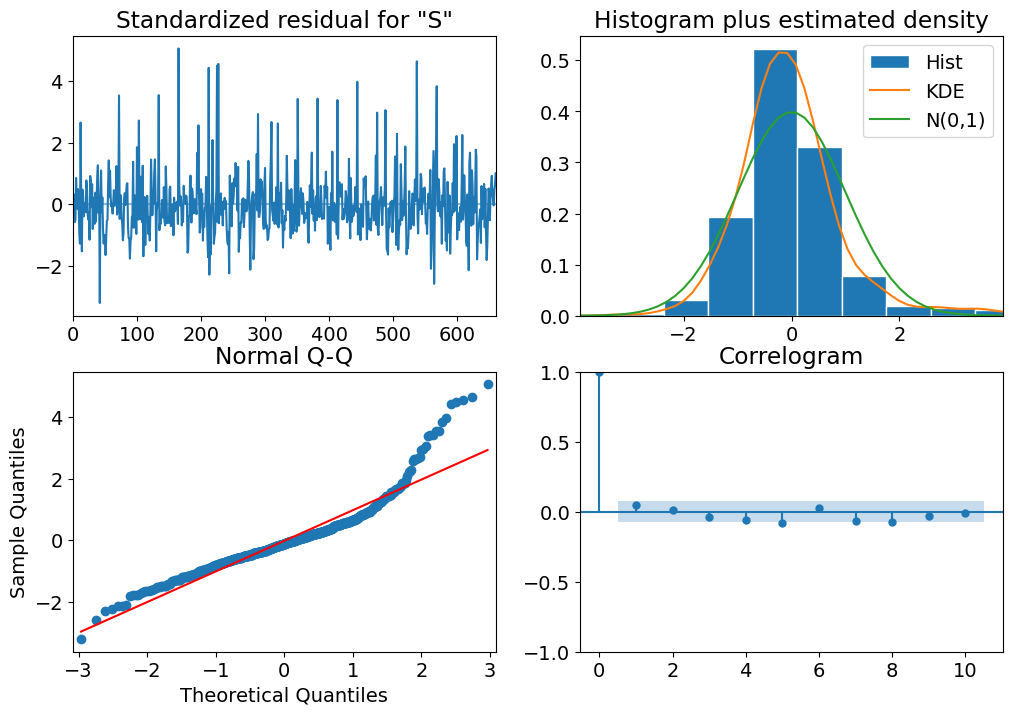

In [40]:
fig = results.plot_diagnostics(figsize=(12,8))

# How to use UnobservedComponents  class from statsmodels


C:\Users\nadia\AppData\Local\Temp\ipykernel_24288\1516426874.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2010-01-01', periods=nobs, freq='M')


                            Unobserved Components Results                            
Dep. Variable:                             y   No. Observations:                  100
Model:                           local level   Log Likelihood                -241.225
                   + stochastic seasonal(12)   AIC                            488.450
Date:                       Fri, 10 Apr 2026   BIC                            495.882
Time:                               16:28:05   HQIC                           491.444
Sample:                           01-31-2010                                         
                                - 04-30-2018                                         
Covariance Type:                         opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  3.021e-08      1.258    2.4e-08      1

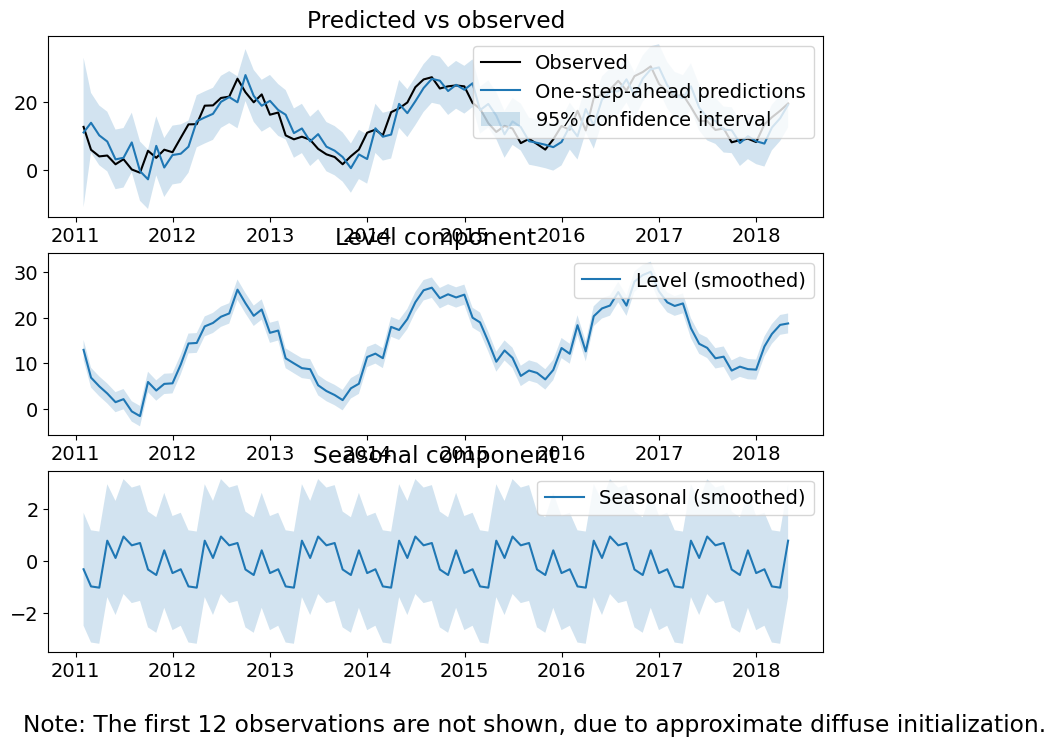

In [41]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate dummy monthly data with a seasonal pattern
np.random.seed(42)
nobs = 100
# Trend + Seasonality (sin wave) + Noise
data = np.linspace(10, 20, nobs) + \
       10 * np.sin(np.linspace(0, 8*np.pi, nobs)) + \
       np.random.normal(0, 2, nobs)
dates = pd.date_range(start='2010-01-01', periods=nobs, freq='M')
ts = pd.Series(data, index=dates)

# 2. Define and Fit the Unobserved Components Model
# 'local level' = stochastic trend, seasonal=12 = monthly seasonality
model = sm.tsa.UnobservedComponents(ts, level='local level', seasonal=12)
res = model.fit(disp=False)

# 3. Print the summary
print(res.summary())

# 4. Plot the decomposition (Trend, Seasonal, Irregular)
fig = res.plot_components(figsize=(10, 8))
plt.show()

In [42]:
def fourier_terms(n, period, K):
    t = np.arange(n)
    X = []
    
    for k in range(1, K+1):
        X.append(np.sin(2*np.pi*k*t/period))
        X.append(np.cos(2*np.pi*k*t/period))
    
    return np.column_stack(X)

# Intraday seasonality
period = 78
K = 10  # number of harmonics

X = fourier_terms(len(y), period, K)

In [43]:
# unobserved components model 
from statsmodels.tsa.statespace.structural import UnobservedComponents

ucm_model = UnobservedComponents(
    y_log,
    level='local level',     # time-varying mean
    exog=X                  # Fourier seasonal terms
)

ucm_res = ucm_model.fit()

ucm_fitted = ucm_res.fittedvalues

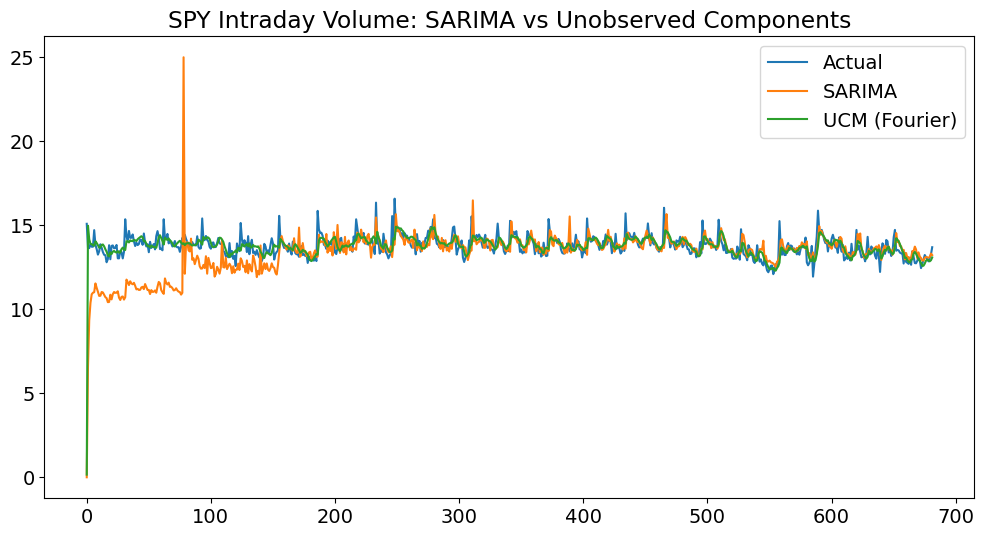

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_log.values, label="Actual")
plt.plot(sarima_fitted, label="SARIMA")
plt.plot(ucm_fitted, label="UCM (Fourier)")

plt.legend()
plt.title("SPY Intraday Volume: SARIMA vs Unobserved Components")
plt.show()

C:\Users\nadia\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\structural.py:426: SpecificationWarning: Value of `stochastic_level` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
C:\Users\nadia\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\structural.py:1738: RuntimeWarning: invalid value encountered in sqrt
  std_errors = np.sqrt(component_bunch['%s_cov' % which])


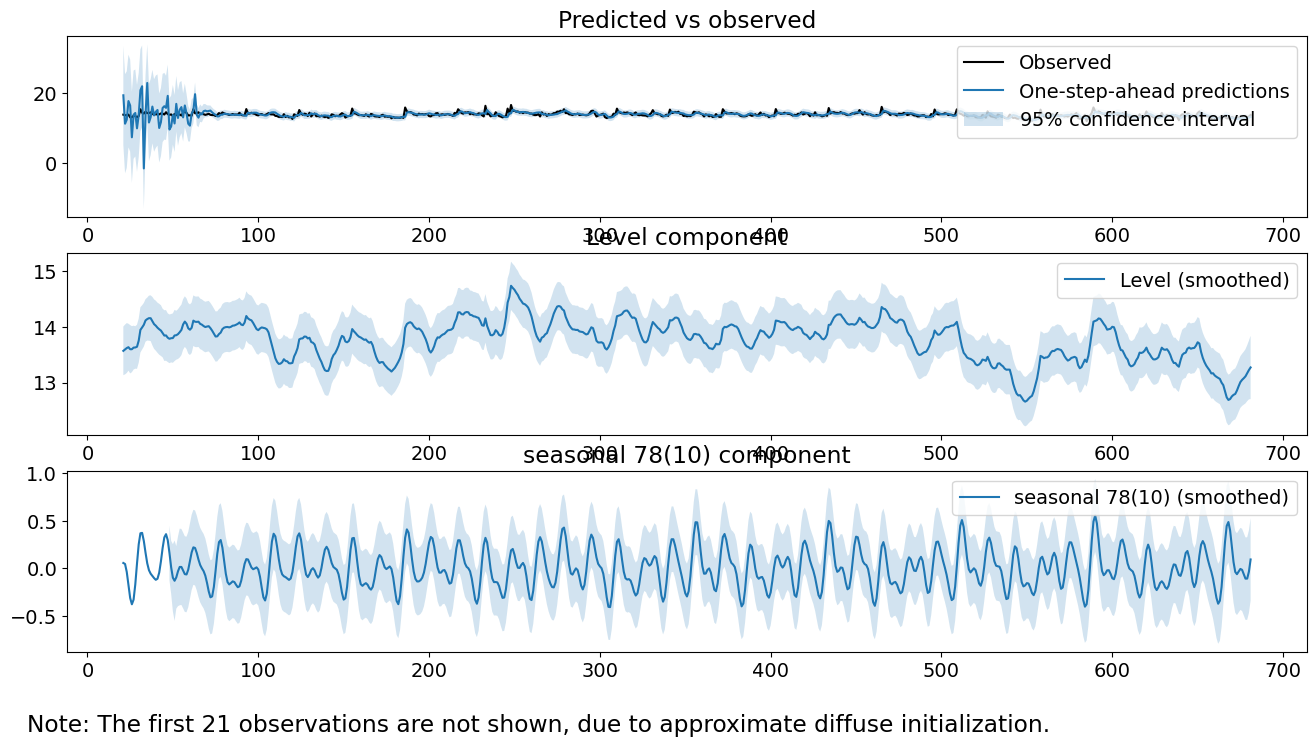

In [23]:

model = sm.tsa.UnobservedComponents(y_log,
                                     level='local level',
                                     freq_seasonal=[{'period': 78, 'harmonics': 10}],
                                     stochastic_level=True)
rs2 = model.fit()
rs2_fitted = rs2.fittedvalues
# Extract components (trend, seasonal, irregular)
components = rs2.plot_components()

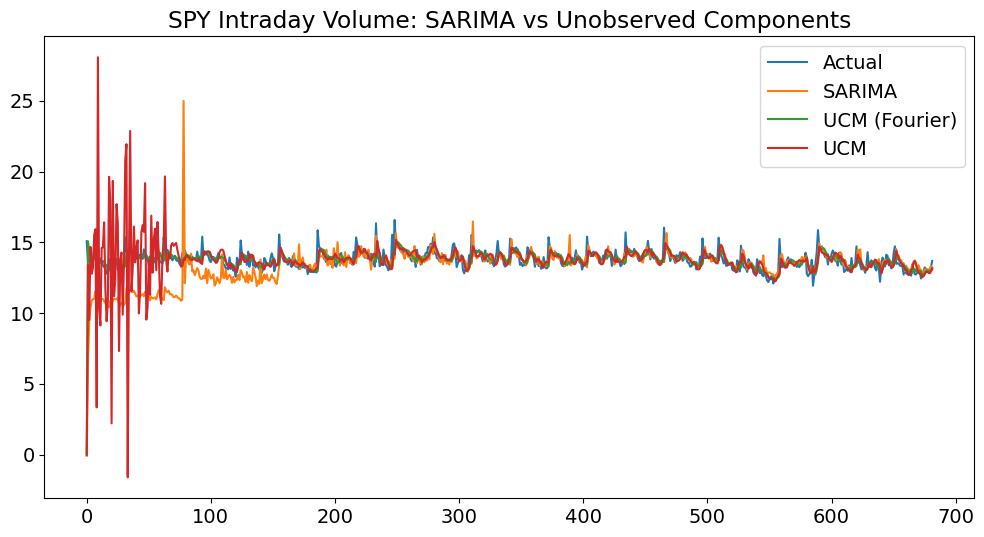

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_log.values, label="Actual")
plt.plot(sarima_fitted, label="SARIMA")
plt.plot(ucm_fitted, label="UCM (Fourier)")
plt.plot(rs2_fitted, label="UCM")

plt.legend()
plt.title("SPY Intraday Volume: SARIMA vs Unobserved Components")
plt.show()
